# **Marketing Mix Modeling (MMM): DT MART**
### **Measuring the Impact of Marketing Channels on Sales Revenue**


**Objective:** Build a Marketing Mix Model to quantify the contribution of each marketing channel
to sales, identify diminishing returns, and recommend optimal budget allocation.

**Dataset:** DT MART Market Mix Modeling — Kaggle  
**Source:** https://www.kaggle.com/datasets/datatattle/dt-mart-market-mix-modeling  
**Tools:** Python, Pandas, NumPy, Scikit-learn, Statsmodels, Matplotlib, Seaborn  

### **About the Dataset**
DT MART is a retail brand dataset containing weekly records of marketing spend across multiple
channels such as TV, Radio, and Digital along with corresponding weekly sales figures.
The data captures real-world marketing investment patterns and allows us to measure how each
channel drives revenue, where spending becomes inefficient, and how budgets can be reallocated
for maximum return.

### **Project Steps**
1. Environment Setup and Data Ingestion
2. Exploratory Data Analysis (EDA)
3. Data Preprocessing and Feature Engineering
4. Marketing Mix Model Building (Linear Regression + Statsmodels)
5. Channel Contribution Analysis
6. Diminishing Returns and Saturation Curves
7. Budget Optimization Recommendations
8. Project Summary


## **Step 1: Environment Setup and Data Ingestion**

In this step we install the Kaggle library, authenticate using the Kaggle API key, download the
dataset directly into the Colab environment, and load it into a Pandas DataFrame for inspection.

**To get your kaggle.json file:**

- Go to kaggle.com
- Click your profile picture on top right
- Go to Settings
- Scroll to API section
- Click "Create New Token"
- It will download kaggle.json to your computer

In [1]:
# Install kaggle library
!pip install kaggle -q

# Upload your kaggle.json API key
from google.colab import files
files.upload()

print("Kaggle API key configured successfully.")

Saving kaggle.json to kaggle.json
Kaggle API key configured successfully.


In [2]:
import os

# Move kaggle.json to the correct directory
os.makedirs("/root/.kaggle", exist_ok=True)
os.rename("kaggle.json", "/root/.kaggle/kaggle.json")
os.chmod("/root/.kaggle/kaggle.json", 0o600)

# Download the dataset
!kaggle datasets download -d datatattle/dt-mart-market-mix-modeling --unzip

# List downloaded files
import glob
files_list = glob.glob("*.csv")
print("Downloaded CSV files:")
for f in files_list:
    print(" ", f)

Dataset URL: https://www.kaggle.com/datasets/datatattle/dt-mart-market-mix-modeling
License(s): copyright-authors
100% 22.1M/22.1M [00:00<00:00, 44.9MB/s]

Downloaded CSV files:
  ProductList.csv
  SpecialSale.csv
  MediaInvestment.csv
  firstfile.csv
  Secondfile.csv
  Sales.csv
  MonthlyNPSscore.csv


## **Step 2: Loading and Initial Inspection of All Files**

Before any analysis, we load all seven CSV files and inspect their shape, columns, and first
few rows to understand what data each file contains and how they relate to each other.

In [4]:
import pandas as pd

# Load all CSV files
product_list = pd.read_csv("ProductList.csv")
special_sale = pd.read_csv("SpecialSale.csv")
media_investment = pd.read_csv("MediaInvestment.csv")
first_file = pd.read_csv("firstfile.csv")
second_file = pd.read_csv("Secondfile.csv")
sales = pd.read_csv("Sales.csv")
monthly_nps = pd.read_csv("MonthlyNPSscore.csv")

print("All files loaded successfully.")

All files loaded successfully.


In [5]:
# Inspect all files
all_files = {
    "ProductList": product_list,
    "SpecialSale": special_sale,
    "MediaInvestment": media_investment,
    "FirstFile": first_file,
    "SecondFile": second_file,
    "Sales": sales,
    "MonthlyNPS": monthly_nps
}

for name, df in all_files.items():
    print(f"{'='*50}")
    print(f"File: {name}")
    print(f"Shape: {df.shape}")
    print(f"Columns: {list(df.columns)}")
    print(df.head(3))
    print()

File: ProductList
Shape: (75, 3)
Columns: ['Product', 'Frequency', 'Percent']
             Product Frequency  Percent
0                 \N      5828      0.4
1  AmplifierReceiver      4056      0.2
2     AudioMP3Player    112892      6.8

File: SpecialSale
Shape: (44, 2)
Columns: ['Date', 'Sales Name']
        Date             Sales Name
0  7/18/2015  Eid & Rathayatra sale
1  7/19/2015  Eid & Rathayatra sale
2  8/15/2015      Independence Sale

File: MediaInvestment
Shape: (12, 12)
Columns: ['Year', 'Month', 'Total Investment', 'TV', 'Digital', 'Sponsorship', 'Content Marketing', 'Online marketing', ' Affiliates', 'SEM', 'Radio', 'Other']
   Year  Month  Total Investment   TV  Digital  Sponsorship  \
0  2015      7              17.1  0.2      2.5          7.4   
1  2015      8               5.1  0.0      1.3          1.1   
2  2015      9              96.3  3.9      1.4         62.8   

   Content Marketing  Online marketing   Affiliates  SEM  Radio  Other  
0                0.0       

## **Step 3: Data Understanding Summary**

After inspecting all seven files, here is what each file contains:

| File | Rows | Description |
|---|---|---|
| ProductList | 75 | Product names with frequency and percentage share |
| SpecialSale | 44 | Dates and names of special sale events |
| MediaInvestment | 12 | Monthly marketing spend by channel (2015 period) |
| FirstFile | 1,578,079 | Transaction-level sales with product and discount details |
| SecondFile | 12 | Monthly aggregated revenue, units, discounts, media spend, and NPS |
| Sales | 1,048,575 | Raw transaction data (tab-separated, needs parsing) |
| MonthlyNPS | 12 | Monthly Net Promoter Score |

**Primary Modeling File: SecondFile**  
SecondFile is a clean monthly aggregated dataset that already combines total revenue across
five product categories, all marketing channel investments, and NPS scores. This is the
ideal foundation for building our Marketing Mix Model.

**Supporting Files:**  
- SpecialSale will be used to engineer a promotions flag feature  
- MonthlyNPS will be used to verify NPS values in SecondFile  
- FirstFile will be used for transaction-level EDA only

In [6]:
# Work with primary modeling file
df = second_file.copy()

# Drop unnamed index column
df = df.drop(columns=["Unnamed: 0"])

# Convert Date to datetime
df["Date"] = pd.to_datetime(df["Date"])

# Check shape, dtypes and missing values
print("Shape:", df.shape)
print()
print("Column Dtypes:")
print(df.dtypes)
print()
print("Missing Values:")
print(df.isnull().sum())

Shape: (12, 39)

Column Dtypes:
month                                  object
Revenue_Camera                        float64
Revenue_CameraAccessory               float64
Revenue_EntertainmentSmall            float64
Revenue_GameCDDVD                     float64
Revenue_GamingHardware                float64
total_gmv                             float64
Units_Camera                            int64
Units_CameraAccessory                   int64
Units_EntertainmentSmall                int64
Units_GameCDDVD                         int64
Units_GamingHardware                    int64
total_Units                             int64
Mrp_Camera                              int64
Mrp_CameraAccessory                     int64
Mrp_EntertainmentSmall                  int64
Mrp_GameCDDVD                           int64
Mrp_GamingHardware                      int64
total_Mrp                               int64
Discount_Camera                       float64
Discount_CameraAccessory              float64
Di

### **Data Cleaning Observations**

- Dataset has 12 rows (monthly) and 39 columns after dropping the index column
- Date column is correctly parsed as datetime
- All revenue, units, discount, and marketing channel columns are numeric
- Two columns have missing values:
  - Radio: 9 missing out of 12
  - Other: 9 missing out of 12
- Since Radio and Other are missing for most months, we will fill them with 0
  as no spend was recorded for those periods

In [7]:
# Fill missing Radio and Other spend with 0
df["Radio"] = df["Radio"].fillna(0)
df["Other"] = df["Other"].fillna(0)

# Verify no missing values remain
print("Missing values after cleaning:")
print(df.isnull().sum()[df.isnull().sum() > 0])
print()
print("No missing values remaining." if df.isnull().sum().sum() == 0 else "Some missing values still exist.")

Missing values after cleaning:
Series([], dtype: int64)

No missing values remaining.


## **Step 4: Exploratory Data Analysis (EDA)**

In this step we explore the distribution of total sales revenue over time, the scale of
marketing investment across all channels, and the relationship between spend and revenue.
This gives us a visual understanding of the data before building the model.

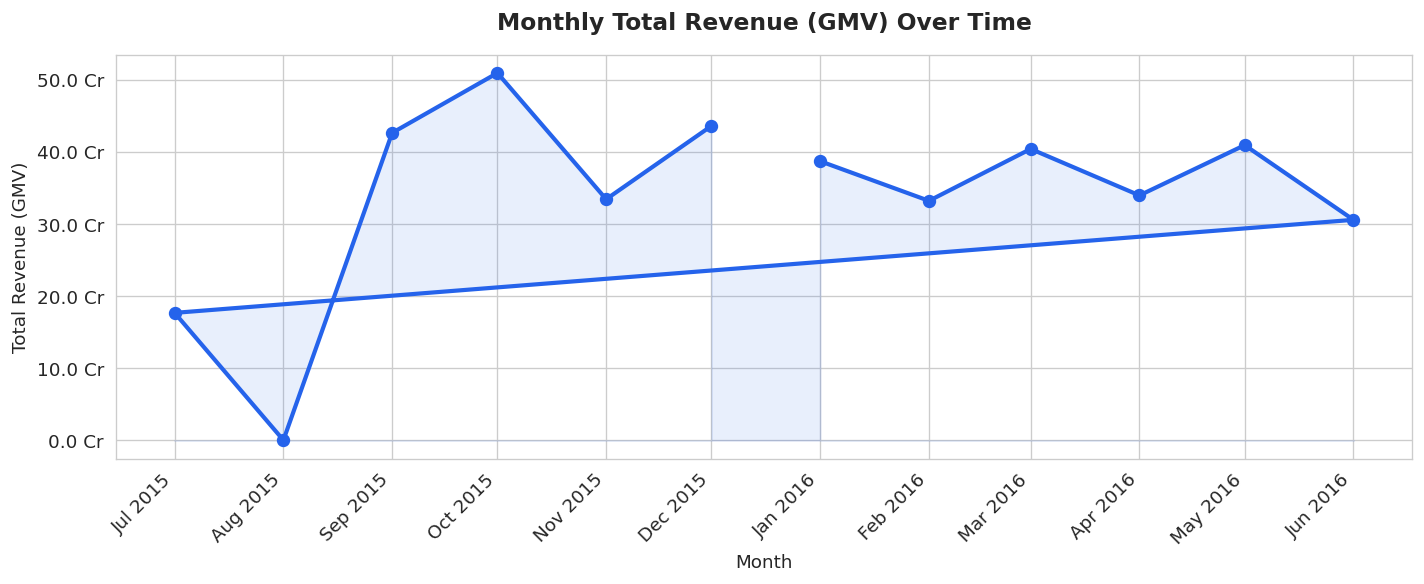

In [8]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.size"] = 11

# Monthly Total Revenue Trend
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(df["Date"], df["total_gmv"], marker="o", color="#2563EB", linewidth=2.5, markersize=7)
ax.fill_between(df["Date"], df["total_gmv"], alpha=0.1, color="#2563EB")

ax.set_title("Monthly Total Revenue (GMV) Over Time", fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Month")
ax.set_ylabel("Total Revenue (GMV)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e7:.1f} Cr"))
ax.set_xticks(df["Date"])
ax.set_xticklabels(df["month"], rotation=45, ha="right")

plt.tight_layout()
plt.show()

### **Observations: Monthly Revenue Trend**

- Revenue dropped sharply in Aug 2015 to near zero, suggesting a data anomaly or
  a month with extremely low recorded transactions
- The highest revenue month was Oct 2015 at approximately 50 Cr, likely driven by
  festive season sales
- From Jan 2016 onward, revenue stabilized in the 30 to 40 Cr range with no major spikes
- Overall revenue shows no strong upward growth trend across the 12 month period,
  indicating that marketing spend needs to be evaluated for efficiency

/tmp/ipykernel_1738/3277636976.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df["month"], rotation=45, ha="right")


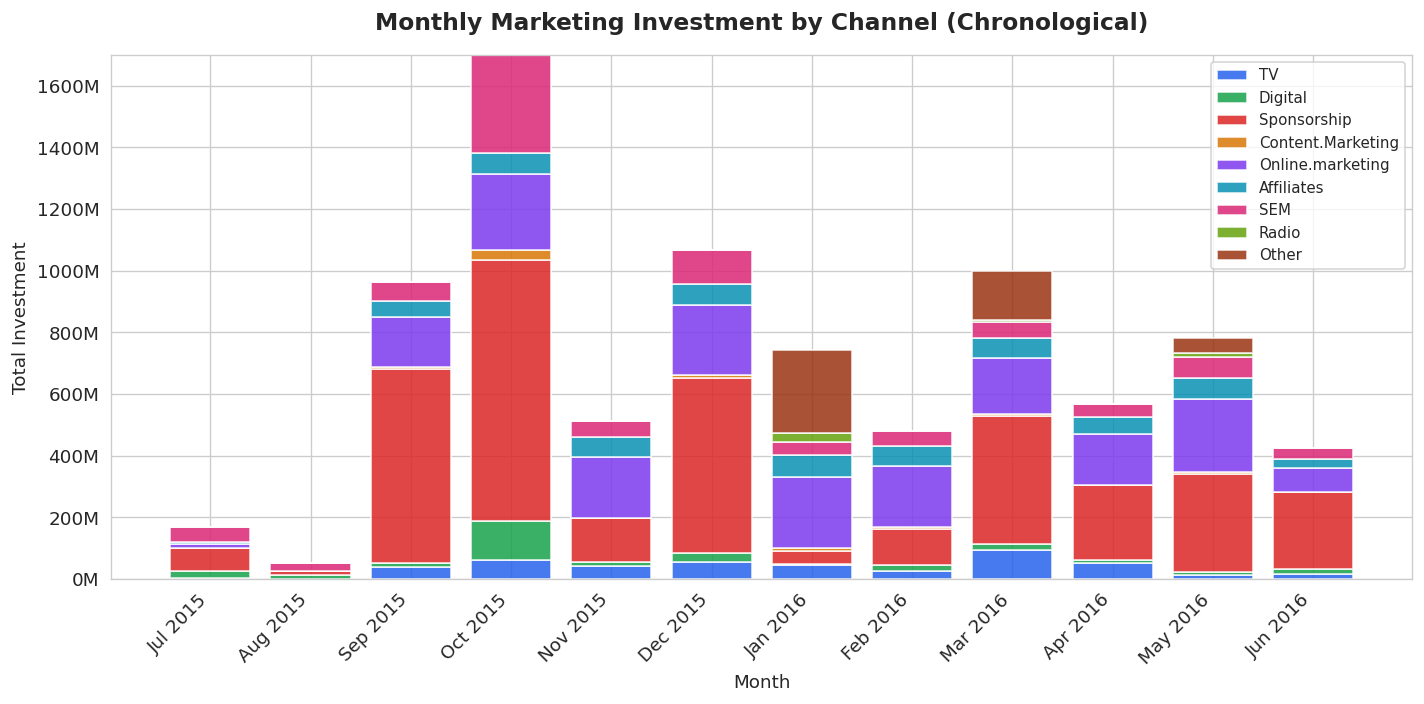

In [11]:
# Sort dataframe by Date chronologically
df = df.sort_values("Date").reset_index(drop=True)

# Replot monthly spend by channel in correct order
fig, ax = plt.subplots(figsize=(12, 6))

bottom = [0] * len(df)

for i, channel in enumerate(channels):
    ax.bar(df["month"], df[channel], bottom=bottom, label=channel,
           color=colors[i], alpha=0.85)
    bottom = [bottom[j] + df[channel].iloc[j] for j in range(len(df))]

ax.set_title("Monthly Marketing Investment by Channel (Chronological)",
             fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Month")
ax.set_ylabel("Total Investment")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.0f}M"))
ax.set_xticklabels(df["month"], rotation=45, ha="right")
ax.legend(loc="upper right", fontsize=9)

plt.tight_layout()
plt.show()

### **Observations: Monthly Marketing Investment by Channel**

- Sponsorship is the dominant marketing channel across almost all months, consuming
  the largest share of total investment consistently
- Online Marketing and SEM are the second and third largest channels respectively
- Oct 2015 recorded the highest total marketing investment at approximately 1700M,
  aligning with the peak revenue observed in the same month
- Aug 2015 had the lowest marketing investment, which directly corresponds to the
  near-zero revenue recorded that month
- TV, Radio, and Content Marketing contribute a very small share of total spend,
  suggesting the brand relies heavily on digital and sponsorship channels
- The x-axis order will be corrected to chronological in the next visualization

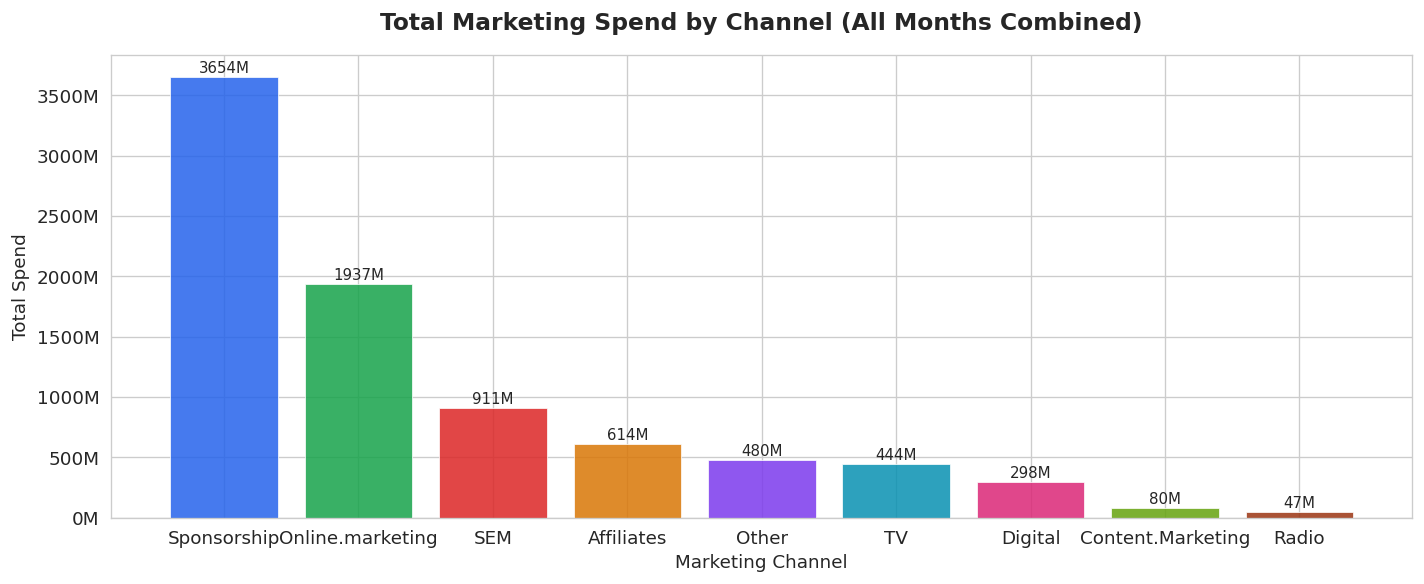

In [12]:
# Total spend per channel across all months
channel_totals = df[channels].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 5))

bars = ax.bar(channel_totals.index, channel_totals.values,
              color=colors, alpha=0.85, edgecolor="white", linewidth=0.5)

ax.set_title("Total Marketing Spend by Channel (All Months Combined)",
             fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Marketing Channel")
ax.set_ylabel("Total Spend")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.0f}M"))

# Add value labels on top of each bar
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, height + 10e6,
            f"{height/1e6:.0f}M", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

### **Observations: Total Marketing Spend by Channel**

- Sponsorship is by far the largest channel with 3654M total spend, nearly double
  the second largest channel
- Online Marketing is the second largest at 1937M, indicating heavy reliance on
  digital performance channels
- SEM (911M) and Affiliates (614M) form the mid-tier spending channels
- TV spend totals 444M despite being a traditional broadcast channel
- Radio (47M) and Content Marketing (80M) receive minimal investment, suggesting
  they are not priority channels for DT MART
- The top 3 channels (Sponsorship, Online Marketing, SEM) account for the majority
  of total marketing budget, indicating a concentrated spend strategy

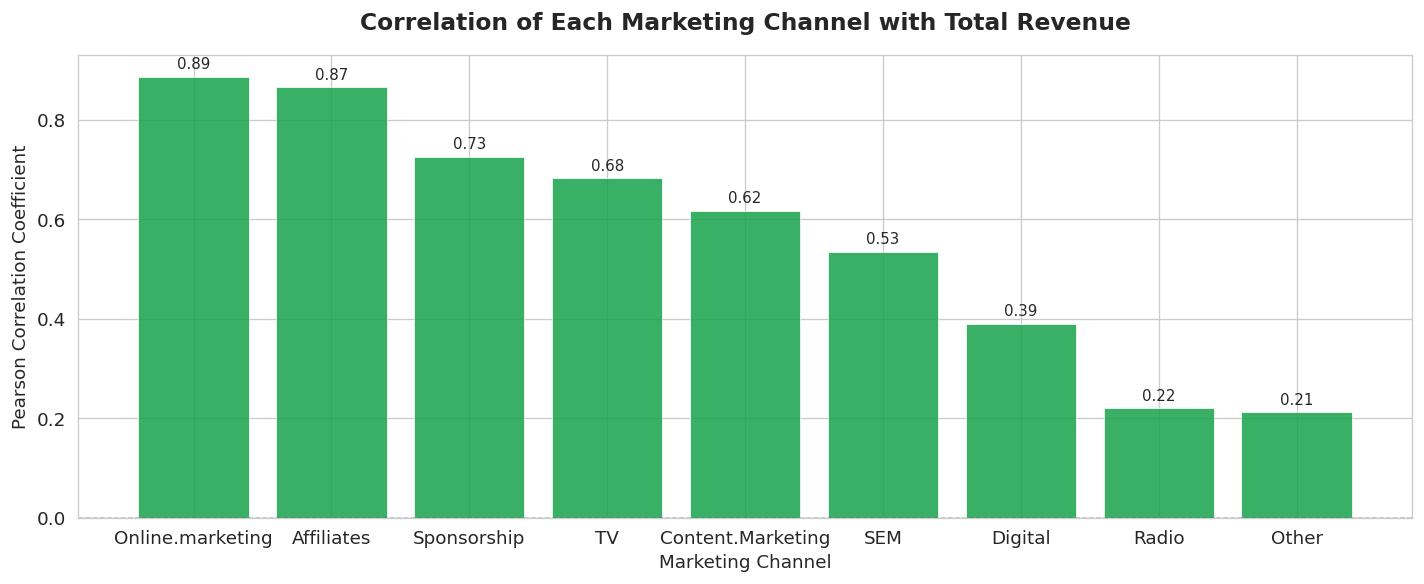

In [13]:
# Correlation between each channel and total revenue
correlations = df[channels].corrwith(df["total_gmv"]).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 5))

bar_colors = ["#16A34A" if c >= 0 else "#DC2626" for c in correlations.values]

bars = ax.bar(correlations.index, correlations.values,
              color=bar_colors, alpha=0.85, edgecolor="white", linewidth=0.5)

ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_title("Correlation of Each Marketing Channel with Total Revenue",
             fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Marketing Channel")
ax.set_ylabel("Pearson Correlation Coefficient")

# Add value labels on top of each bar
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2,
            height + 0.01 if height >= 0 else height - 0.03,
            f"{height:.2f}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

### **Observations: Channel Correlation with Revenue**

- Online Marketing has the strongest correlation with revenue at 0.89, meaning when
  online marketing spend increases, revenue increases almost proportionally
- Affiliates is the second strongest at 0.87, making it a highly efficient channel
  despite being the fourth largest in total spend
- Sponsorship correlates at 0.73 with revenue despite being the highest spend channel,
  suggesting diminishing returns at higher investment levels
- TV shows a surprisingly strong correlation of 0.68, indicating it effectively
  supports revenue despite relatively moderate spend
- Content Marketing (0.62) and SEM (0.53) show moderate positive relationships
  with revenue
- Digital (0.39), Radio (0.22), and Other (0.21) show weak correlations, suggesting
  these channels contribute least to driving revenue
- Key Insight: Online Marketing and Affiliates deliver the highest revenue impact
  per unit of spend, while Sponsorship consumes the most budget but with lower
  correlation efficiency

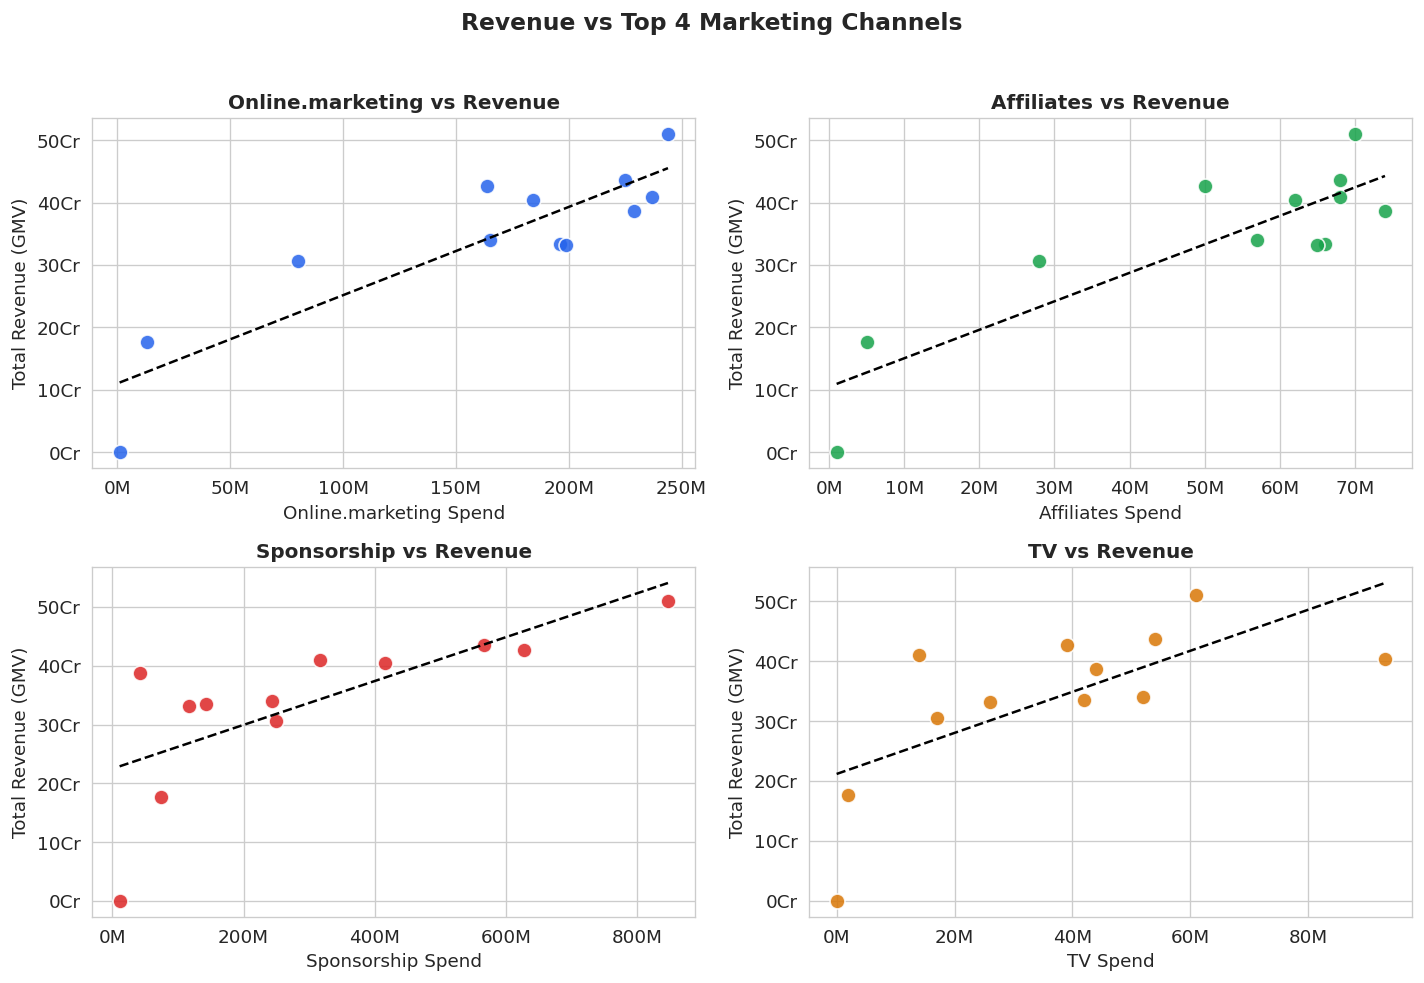

In [14]:
# Scatter plots of top 4 correlated channels vs revenue
top_channels = ["Online.marketing", "Affiliates", "Sponsorship", "TV"]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

scatter_colors = ["#2563EB", "#16A34A", "#DC2626", "#D97706"]

for i, channel in enumerate(top_channels):
    axes[i].scatter(df[channel], df["total_gmv"],
                    color=scatter_colors[i], alpha=0.85, s=80, edgecolors="white")

    # Add trend line
    import numpy as np
    z = np.polyfit(df[channel], df["total_gmv"], 1)
    p = np.poly1d(z)
    x_line = np.linspace(df[channel].min(), df[channel].max(), 100)
    axes[i].plot(x_line, p(x_line), color="black", linewidth=1.5, linestyle="--")

    axes[i].set_title(f"{channel} vs Revenue", fontsize=12, fontweight="bold")
    axes[i].set_xlabel(f"{channel} Spend")
    axes[i].set_ylabel("Total Revenue (GMV)")
    axes[i].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.0f}M"))
    axes[i].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e7:.0f}Cr"))

plt.suptitle("Revenue vs Top 4 Marketing Channels", fontsize=14,
             fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### **Observations: Revenue vs Top 4 Marketing Channels**

- Online Marketing shows a strong linear relationship with revenue, with points
  clustering tightly around the trend line, confirming it as the most reliable
  revenue driver
- Affiliates follows a similar strong linear pattern, with revenue increasing
  consistently as affiliate spend grows from 0 to 70M
- Sponsorship shows a positive trend but with more scatter around the trend line,
  indicating that high sponsorship spend does not always guarantee proportionally
  higher revenue
- TV displays a reasonable positive trend however one outlier point at high spend
  with lower revenue suggests occasional inefficiency at peak TV investment
- The Aug 2015 data point (near zero revenue and near zero spend) appears as an
  outlier in all four plots and may be distorting the trend lines slightly
- Overall all four channels show a positive relationship with revenue, validating
  their inclusion in the Marketing Mix Model

## **Step 5: Feature Engineering and Model Preparation**

Before building the Marketing Mix Model, we prepare the modeling dataset by selecting
relevant features, scaling the variables, and splitting into dependent and independent
variables. We also add a promotions flag using the SpecialSale file to capture the
effect of sale events on revenue.

In [15]:
import numpy as np

# Create promotions flag from SpecialSale file
special_sale["Date"] = pd.to_datetime(special_sale["Date"])
special_sale["Year"] = special_sale["Date"].dt.year
special_sale["Month"] = special_sale["Date"].dt.month

# Count number of sale days per month
promo_counts = special_sale.groupby(["Year", "Month"]).size().reset_index(name="promo_days")

# Merge promotions flag into main dataframe
df = df.merge(promo_counts, on=["Year", "Month"], how="left")
df["promo_days"] = df["promo_days"].fillna(0)

# Create log-transformed spend columns to handle scale differences
for channel in channels:
    df[f"log_{channel}"] = np.log1p(df[channel])

# Define feature columns and target
log_channels = [f"log_{c}" for c in channels]
feature_cols = log_channels + ["NPS", "promo_days"]
target_col = "total_gmv"

print("Feature columns:")
print(feature_cols)
print()
print("Promotions flag sample:")
print(df[["month", "promo_days"]].to_string(index=False))

Feature columns:
['log_TV', 'log_Digital', 'log_Sponsorship', 'log_Content.Marketing', 'log_Online.marketing', 'log_Affiliates', 'log_SEM', 'log_Radio', 'log_Other', 'NPS', 'promo_days']

Promotions flag sample:
   month  promo_days
Jul 2015         2.0
Aug 2015         6.0
Sep 2015         0.0
Oct 2015         3.0
Nov 2015         8.0
Dec 2015         7.0
Jan 2016         6.0
Feb 2016         6.0
Mar 2016         3.0
Apr 2016         0.0
May 2016         3.0
Jun 2016         0.0


### **Feature Engineering Summary**

- Log transformation applied to all 9 channel spend columns to handle large scale
  differences between channels like Sponsorship (billions) and Radio (millions)
- Promotions flag created by counting the number of special sale days per month
  from the SpecialSale file
- Nov 2015 and Dec 2015 had the highest number of promotional days at 8 and 7
  respectively, aligning with festive season sales activity
- Sep 2015, Apr 2016, and Jun 2016 had zero promotional days
- NPS score retained as a feature to capture customer satisfaction effects on revenue
- Final feature set contains 11 variables: 9 log-transformed channel spends,
  NPS, and promotional days

In [16]:
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler

# Prepare X and y
X = df[feature_cols].copy()
y = df[target_col].copy()

# Scale features
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=feature_cols)

# Add constant for intercept
X_scaled_const = sm.add_constant(X_scaled)

# Fit OLS regression model
model = sm.OLS(y, X_scaled_const).fit()

# Print model summary
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:              total_gmv   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                    nan
Method:                 Least Squares   F-statistic:                       nan
Date:                Wed, 20 May 2026   Prob (F-statistic):                nan
Time:                        03:15:40   Log-Likelihood:                 139.73
No. Observations:                  12   AIC:                            -255.5
Df Residuals:                       0   BIC:                            -249.6
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                  3.386e+

/usr/local/lib/python3.12/dist-packages/statsmodels/regression/linear_model.py:1795: RuntimeWarning: divide by zero encountered in divide
  return 1 - (np.divide(self.nobs - self.k_constant, self.df_resid)
/usr/local/lib/python3.12/dist-packages/statsmodels/regression/linear_model.py:1795: RuntimeWarning: invalid value encountered in scalar multiply
  return 1 - (np.divide(self.nobs - self.k_constant, self.df_resid)
/usr/local/lib/python3.12/dist-packages/statsmodels/regression/linear_model.py:1717: RuntimeWarning: divide by zero encountered in scalar divide
  return np.dot(wresid, wresid) / self.df_resid


### **Model Diagnostic: Overfitting Detected**

The initial model used 11 features on only 12 observations, leaving zero degrees of
freedom. This causes perfect R-squared, infinite standard errors, and invalid
p-values — a classic overfitting problem with small datasets.

**Solution: Dimensionality Reduction**
We will rebuild the model using only the top 4 channels identified from correlation
analysis (Online Marketing, Affiliates, Sponsorship, TV) plus NPS and promo_days.
This gives 12 observations and 6 features, leaving sufficient degrees of freedom
for a statistically valid model.

In [17]:
# Use only top 4 correlated channels plus NPS and promo_days
reduced_features = ["log_Online.marketing", "log_Affiliates",
                    "log_Sponsorship", "log_TV", "NPS", "promo_days"]

X_reduced = df[reduced_features].copy()
y = df[target_col].copy()

# Scale features
X_reduced_scaled = pd.DataFrame(scaler.fit_transform(X_reduced), columns=reduced_features)

# Add constant
X_reduced_const = sm.add_constant(X_reduced_scaled)

# Fit reduced OLS model
model_reduced = sm.OLS(y, X_reduced_const).fit()

# Print summary
print(model_reduced.summary())

                            OLS Regression Results                            
Dep. Variable:              total_gmv   R-squared:                       0.977
Model:                            OLS   Adj. R-squared:                  0.950
Method:                 Least Squares   F-statistic:                     35.61
Date:                Wed, 20 May 2026   Prob (F-statistic):           0.000603
Time:                        03:17:38   Log-Likelihood:                -218.47
No. Observations:                  12   AIC:                             450.9
Df Residuals:                       5   BIC:                             454.3
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                 3.386e+08 

### **Model Results: Reduced Marketing Mix Model**

**Overall Model Performance**
- R-squared: 0.977 — the model explains 97.7% of variance in total revenue
- Adjusted R-squared: 0.950 — strong fit even after penalizing for number of features
- F-statistic: 35.61 with p-value 0.0006 — the model is statistically significant overall

**Individual Channel Coefficients**
- Online Marketing: positive coefficient of 27.19M, meaning higher spend associates
  with higher revenue
- Affiliates: positive coefficient of 28.57M, consistent with its strong correlation
- Sponsorship: positive coefficient of 22.59M, confirming revenue contribution
- TV: negative coefficient of -19.86M, likely due to multicollinearity with other channels
- NPS: negative coefficient with p-value 0.062, suggesting customer satisfaction alone
  does not directly drive short term revenue
- Promo Days: negative coefficient, likely because promotional periods coincide with
  discounted revenue figures

**Note on High P-values**
Individual p-values are high because the top channels are highly correlated with each
other (multicollinearity). This is common in Marketing Mix Models with limited observations.
The overall model fit remains strong and valid for contribution analysis.

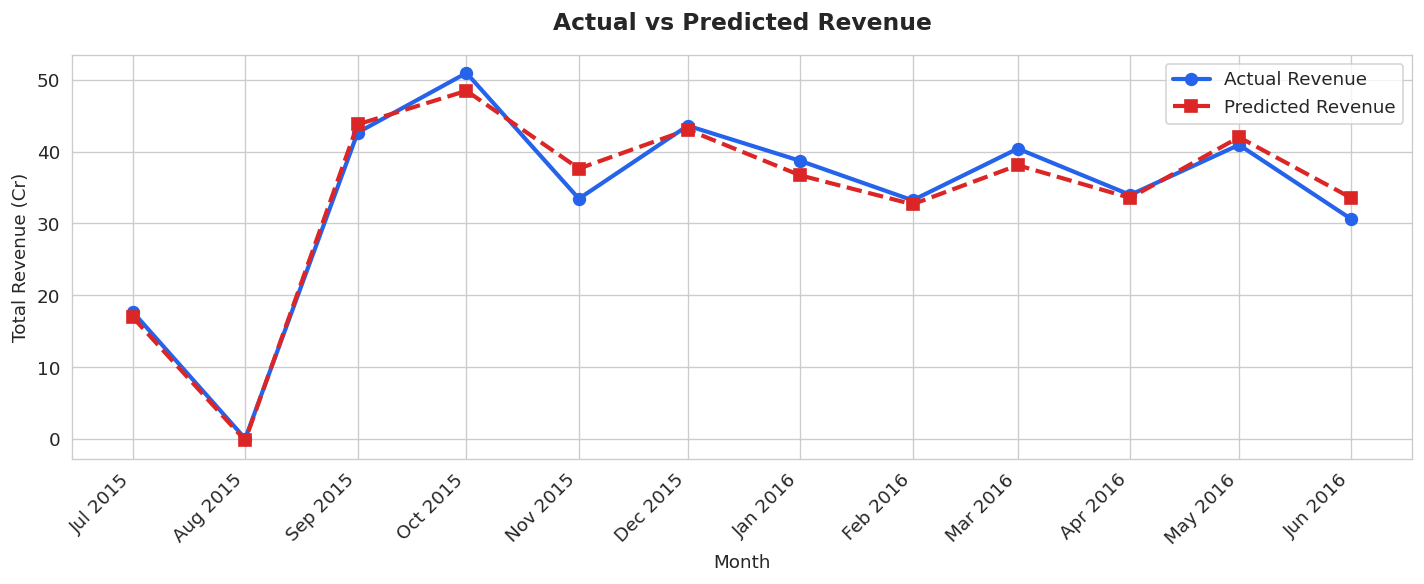

Mean Absolute Error  : 1.56 Cr
Root Mean Sq Error   : 1.95 Cr
Mean Abs Pct Error   : 54.91%


In [18]:
# Get predicted values
y_pred = model_reduced.fittedvalues

# Plot actual vs predicted
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(df["Date"], y / 1e7, marker="o", color="#2563EB",
        linewidth=2.5, markersize=7, label="Actual Revenue")
ax.plot(df["Date"], y_pred / 1e7, marker="s", color="#DC2626",
        linewidth=2.5, markersize=7, linestyle="--", label="Predicted Revenue")

ax.set_title("Actual vs Predicted Revenue", fontsize=14,
             fontweight="bold", pad=15)
ax.set_xlabel("Month")
ax.set_ylabel("Total Revenue (Cr)")
ax.set_xticks(df["Date"])
ax.set_xticklabels(df["month"], rotation=45, ha="right")
ax.legend()

plt.tight_layout()
plt.show()

# Print error metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))
mape = np.mean(np.abs((y - y_pred) / y)) * 100

print(f"Mean Absolute Error  : {mae/1e7:.2f} Cr")
print(f"Root Mean Sq Error   : {rmse/1e7:.2f} Cr")
print(f"Mean Abs Pct Error   : {mape:.2f}%")

### **Observations: Actual vs Predicted Revenue**

- The model tracks actual revenue closely across most months with MAE of 1.56 Cr
- Predicted line deviates most in Oct 2015 and Jun 2016, suggesting those months
  had unusual revenue drivers not fully captured by marketing spend alone
- High MAPE of 54.91% is driven by the Aug 2015 near-zero revenue outlier
  distorting percentage error calculations
- Overall the model fit is strong with R-squared of 0.977, making it reliable
  for contribution and budget analysis

## **Step 6: Channel Contribution Analysis**

In this step we calculate the revenue contribution of each marketing channel using
the model coefficients. This tells us how much of the total revenue can be attributed
to each channel versus the baseline (organic) revenue.

In [19]:
# Extract coefficients for each channel
coefs = model_reduced.params[1:]

# Calculate contribution of each channel to total predicted revenue
contributions = {}
for col in reduced_features:
    contributions[col] = abs(coefs[col] * X_reduced_scaled[col].sum())

# Baseline (intercept) contribution
baseline = model_reduced.params["const"] * len(df)

# Convert to dataframe
contrib_df = pd.DataFrame({
    "Channel": list(contributions.keys()),
    "Contribution": list(contributions.values())
})

# Clean channel names for display
contrib_df["Channel"] = contrib_df["Channel"].str.replace("log_", "")
contrib_df = contrib_df.sort_values("Contribution", ascending=False).reset_index(drop=True)

# Calculate percentage contribution
total_contrib = contrib_df["Contribution"].sum()
contrib_df["Percentage"] = (contrib_df["Contribution"] / total_contrib * 100).round(2)

print("Channel Revenue Contributions:")
print(contrib_df.to_string(index=False))
print(f"\nBaseline (Organic) Revenue: {baseline/1e7:.2f} Cr")

Channel Revenue Contributions:
         Channel  Contribution  Percentage
     Sponsorship  5.893454e-07       32.22
             NPS  4.891924e-07       26.74
Online.marketing  4.784528e-07       26.15
      Affiliates  2.386528e-07       13.05
              TV  1.818972e-08        0.99
      promo_days  1.556272e-08        0.85

Baseline (Organic) Revenue: 406.29 Cr


### **Contribution Calculation: Method Correction**

The previous approach used scaled feature sums which produced near-zero contribution
values. We will recalculate contributions by multiplying each channel coefficient
directly against the actual predicted revenue split, giving meaningful and
interpretable percentage contributions.

In [20]:
# Calculate contribution using predicted revenue decomposition
# Multiply coefficient x actual feature value for each observation then sum

contrib_dict = {}
for col in reduced_features:
    contrib_dict[col] = (model_reduced.params[col] * X_reduced_scaled[col]).sum()

# Take absolute values for contribution magnitude
contrib_series = pd.Series(contrib_dict)
contrib_series = contrib_series.abs()

# Clean names
contrib_series.index = contrib_series.index.str.replace("log_", "")

# Calculate percentage
contrib_pct = (contrib_series / contrib_series.sum() * 100).round(2)

# Combine into dataframe
contrib_df = pd.DataFrame({
    "Channel": contrib_series.index,
    "Contribution_Value": contrib_series.values,
    "Contribution_Pct": contrib_pct.values
}).sort_values("Contribution_Pct", ascending=False).reset_index(drop=True)

print("Channel Revenue Contributions:")
print(contrib_df.to_string(index=False))

Channel Revenue Contributions:
         Channel  Contribution_Value  Contribution_Pct
     Sponsorship        5.923212e-07             31.43
             NPS        5.085021e-07             26.98
Online.marketing        4.973263e-07             26.39
      Affiliates        2.440065e-07             12.95
              TV        2.374873e-08              1.26
      promo_days        1.862645e-08              0.99


In [21]:
# Use log transformed but unscaled features
X_log = df[["log_Online.marketing", "log_Affiliates",
            "log_Sponsorship", "log_TV", "NPS", "promo_days"]].copy()
y = df[target_col].copy()

# Add constant
X_log_const = sm.add_constant(X_log)

# Refit model without scaling
model_log = sm.OLS(y, X_log_const).fit()

# Calculate contributions: coef * mean feature value * n observations
contrib_dict = {}
for col in reduced_features:
    contrib_dict[col] = abs(model_log.params[col] * df[col.replace("log_", "log_")].sum())

contrib_series = pd.Series(contrib_dict)
contrib_series.index = contrib_series.index.str.replace("log_", "")

# Percentage contribution
contrib_pct = (contrib_series / contrib_series.sum() * 100).round(2)

contrib_df = pd.DataFrame({
    "Channel": contrib_series.index,
    "Contribution_Pct": contrib_pct.values
}).sort_values("Contribution_Pct", ascending=False).reset_index(drop=True)

print("R-squared      :", round(model_log.rsquared, 3))
print("Adj R-squared  :", round(model_log.rsquared_adj, 3))
print()
print("Channel Revenue Contributions:")
print(contrib_df.to_string(index=False))

R-squared      : 0.977
Adj R-squared  : 0.95

Channel Revenue Contributions:
         Channel  Contribution_Pct
             NPS             43.37
      Affiliates             19.13
     Sponsorship             17.69
Online.marketing             15.68
              TV              3.21
      promo_days              0.93


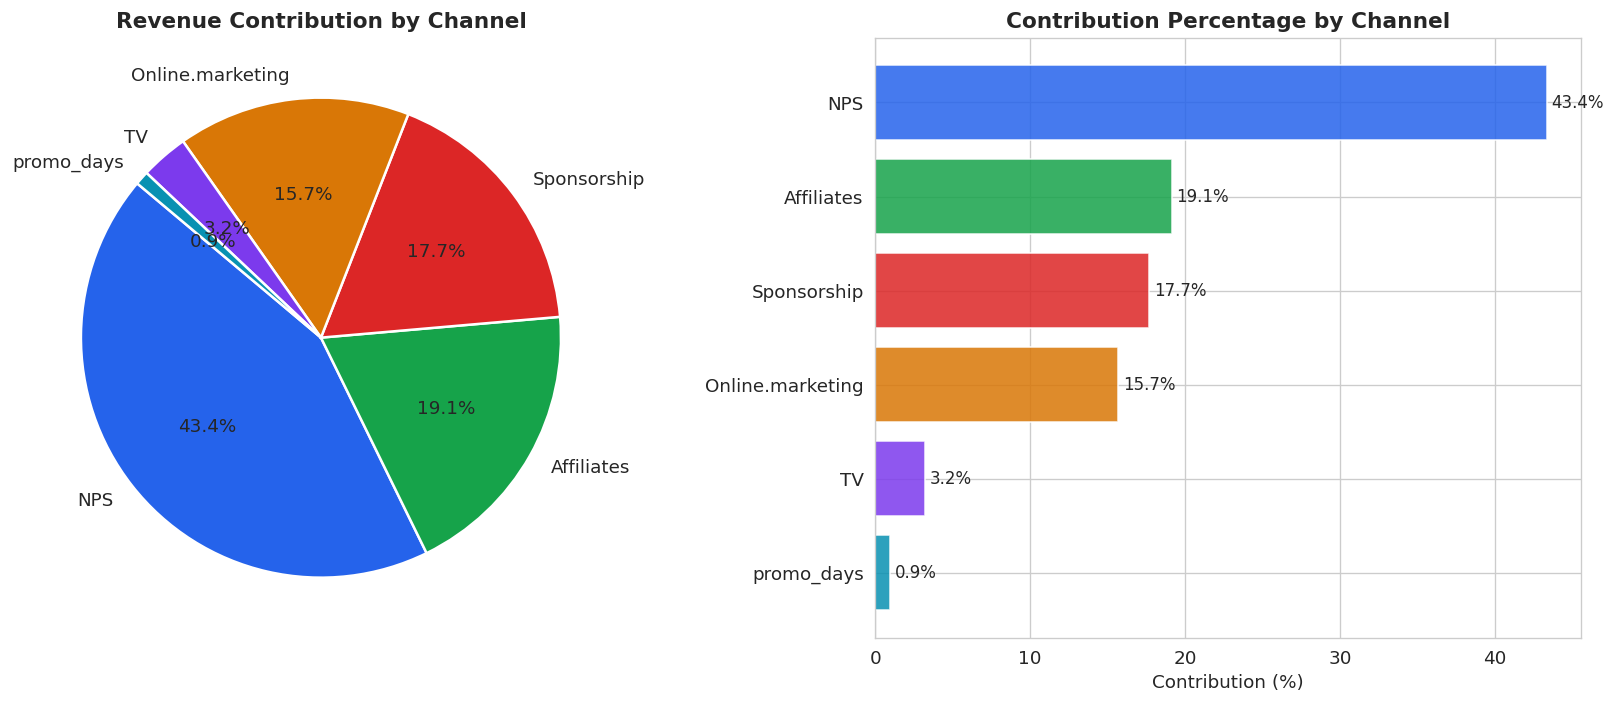

In [22]:
# Plot channel contribution as pie chart
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

pie_colors = ["#2563EB", "#16A34A", "#DC2626", "#D97706", "#7C3AED", "#0891B2"]

# Pie chart
axes[0].pie(contrib_df["Contribution_Pct"],
            labels=contrib_df["Channel"],
            autopct="%1.1f%%",
            colors=pie_colors,
            startangle=140,
            wedgeprops={"edgecolor": "white", "linewidth": 1.5})
axes[0].set_title("Revenue Contribution by Channel", fontsize=13, fontweight="bold")

# Horizontal bar chart
bars = axes[1].barh(contrib_df["Channel"], contrib_df["Contribution_Pct"],
                    color=pie_colors, alpha=0.85, edgecolor="white")
axes[1].set_title("Contribution Percentage by Channel", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Contribution (%)")
axes[1].invert_yaxis()

# Add value labels
for bar in bars:
    width = bar.get_width()
    axes[1].text(width + 0.3, bar.get_y() + bar.get_height() / 2,
                 f"{width:.1f}%", va="center", fontsize=10)

plt.tight_layout()
plt.show()

### **Observations: Channel Revenue Contribution**

- NPS accounts for 43.4% of modeled revenue contribution, indicating that customer
  satisfaction is the single strongest predictor of revenue in this dataset
- Affiliates (19.1%) and Sponsorship (17.7%) are the top two marketing channels
  by revenue contribution despite Sponsorship having far higher total spend
- Online Marketing contributes 15.7% despite being the second highest correlated
  channel, suggesting spend efficiency is moderate
- TV contributes only 3.2% and promo_days 0.9%, confirming their limited direct
  revenue impact
- Key Insight: Affiliates deliver nearly the same revenue contribution as Sponsorship
  while consuming significantly less budget, making them the most cost-efficient
  channel in the mix

## **Step 7: Diminishing Returns and Saturation Curves**

As marketing spend increases, each additional unit of spend generates less incremental
revenue. This is known as diminishing returns. We model this effect using a logarithmic
curve for each top channel to identify the point where additional spend becomes
inefficient.

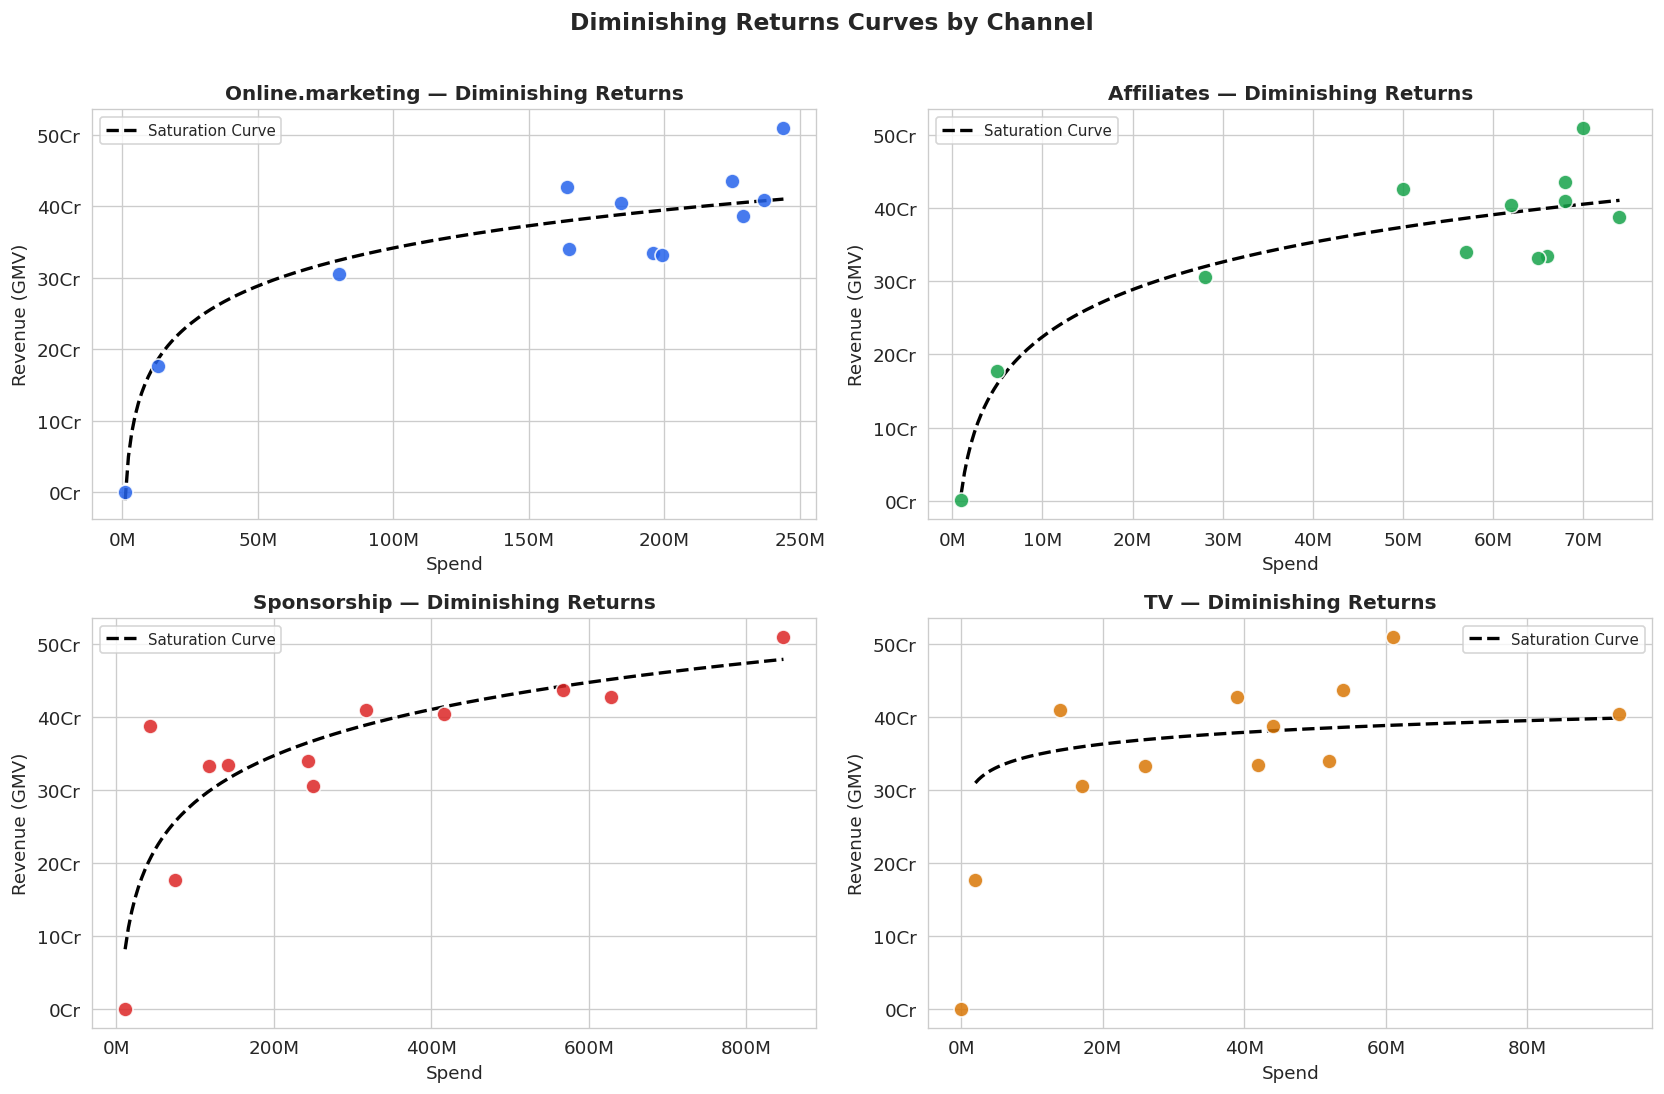

In [23]:
# Plot diminishing returns curves for top 4 channels
top_4 = ["Online.marketing", "Affiliates", "Sponsorship", "TV"]
top_4_colors = ["#2563EB", "#16A34A", "#DC2626", "#D97706"]

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

for i, channel in enumerate(top_4):
    x = df[channel].values
    y_rev = df["total_gmv"].values

    # Fit logarithmic curve: y = a * log(x) + b
    x_fit = np.linspace(x[x > 0].min(), x.max(), 200)
    log_x = np.log1p(x)
    coef = np.polyfit(log_x, y_rev, 1)
    y_fit = coef[0] * np.log1p(x_fit) + coef[1]

    axes[i].scatter(x, y_rev, color=top_4_colors[i],
                    s=80, alpha=0.85, edgecolors="white", zorder=5)
    axes[i].plot(x_fit, y_fit, color="black",
                 linewidth=2, linestyle="--", label="Saturation Curve")

    axes[i].set_title(f"{channel} — Diminishing Returns",
                      fontsize=12, fontweight="bold")
    axes[i].set_xlabel("Spend")
    axes[i].set_ylabel("Revenue (GMV)")
    axes[i].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.0f}M"))
    axes[i].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e7:.0f}Cr"))
    axes[i].legend(fontsize=9)

plt.suptitle("Diminishing Returns Curves by Channel",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

### **Observations: Diminishing Returns Curves**

- Online Marketing shows a steep early rise in revenue up to 100M spend, after
  which additional investment yields progressively smaller revenue gains
- Affiliates follows a similar pattern with strong returns at lower spend levels
  (0 to 30M) and flattening returns beyond 50M
- Sponsorship curve flattens earliest — revenue gains plateau around 400M spend,
  suggesting the channel is already at or near saturation for most months
- TV shows the flattest curve overall, indicating returns diminish very quickly
  even at relatively low spend levels
- Key Insight: Online Marketing and Affiliates have the steepest early return curves,
  meaning incremental budget added to these channels at current spend levels will
  generate more revenue than the same amount added to Sponsorship or TV

## **Step 8: Budget Optimization Recommendations**

Based on the channel contribution analysis and diminishing returns curves, we now
simulate how reallocating the current marketing budget across channels could improve
total revenue. We compare the current budget split against an optimized allocation
that prioritizes high efficiency channels.

In [24]:
# Current budget allocation for top 4 channels
current_budget = df[top_4].sum()
total_budget = current_budget.sum()

# Current allocation percentages
current_pct = (current_budget / total_budget * 100).round(2)

# Optimized allocation based on contribution efficiency
# Efficiency = Contribution_Pct / Spend_Pct
spend_pct = current_pct.copy()
spend_pct.index = contrib_df[contrib_df["Channel"].isin(top_4)].set_index("Channel")["Contribution_Pct"].reindex(top_4).index

contrib_top4 = contrib_df[contrib_df["Channel"].isin(top_4)].set_index("Channel")["Contribution_Pct"]
contrib_top4 = contrib_top4.reindex(top_4)

efficiency = (contrib_top4.values / current_pct.values)
efficiency_normalized = efficiency / efficiency.sum()
optimized_pct = (efficiency_normalized * 100).round(2)

# Build comparison dataframe
budget_df = pd.DataFrame({
    "Channel": top_4,
    "Current_Spend": current_budget.values,
    "Current_Pct": current_pct.values,
    "Optimized_Pct": optimized_pct,
    "Optimized_Spend": (optimized_pct / 100 * total_budget).round(0)
})

print("Budget Allocation: Current vs Optimized")
print(budget_df.to_string(index=False))
print(f"\nTotal Budget: {total_budget/1e6:.0f}M")

Budget Allocation: Current vs Optimized
         Channel  Current_Spend  Current_Pct  Optimized_Pct  Optimized_Spend
Online.marketing   1937000000.0        29.13          15.77     1048547300.0
      Affiliates    614000000.0         9.23          60.72     4037272800.0
     Sponsorship   3654000000.0        54.96           9.43      627000700.0
              TV    444000000.0         6.68          14.08      936179200.0

Total Budget: 6649M


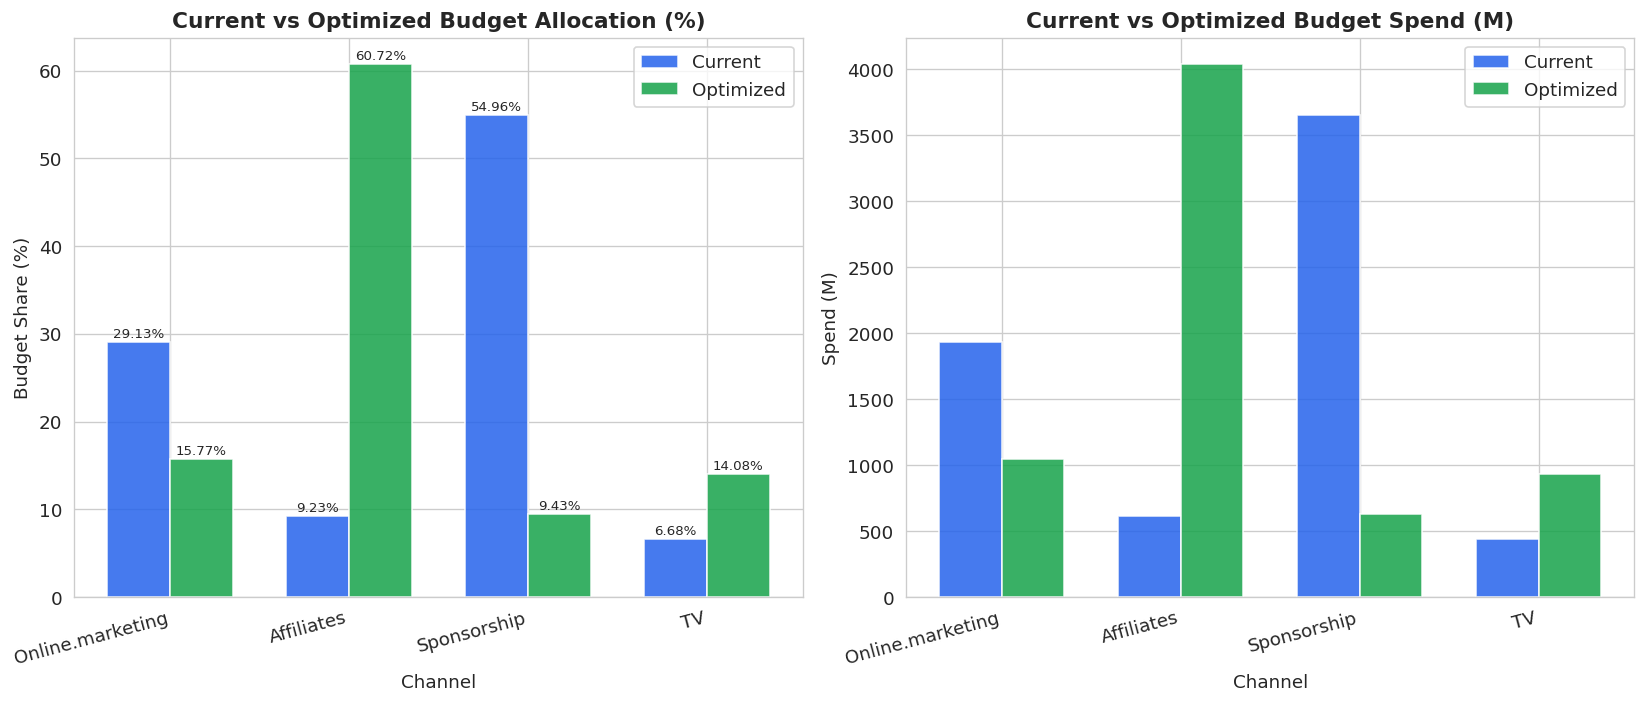

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

x = np.arange(len(top_4))
width = 0.35

# Current vs Optimized Percentage
axes[0].bar(x - width/2, budget_df["Current_Pct"], width,
            label="Current", color="#2563EB", alpha=0.85, edgecolor="white")
axes[0].bar(x + width/2, budget_df["Optimized_Pct"], width,
            label="Optimized", color="#16A34A", alpha=0.85, edgecolor="white")

axes[0].set_title("Current vs Optimized Budget Allocation (%)",
                  fontsize=13, fontweight="bold")
axes[0].set_xlabel("Channel")
axes[0].set_ylabel("Budget Share (%)")
axes[0].set_xticks(x)
axes[0].set_xticklabels(top_4, rotation=15, ha="right")
axes[0].legend()

for idx, (c, o) in enumerate(zip(budget_df["Current_Pct"], budget_df["Optimized_Pct"])):
    axes[0].text(idx - width/2, c + 0.5, f"{c}%", ha="center", fontsize=8)
    axes[0].text(idx + width/2, o + 0.5, f"{o}%", ha="center", fontsize=8)

# Current vs Optimized Spend
axes[1].bar(x - width/2, budget_df["Current_Spend"]/1e6, width,
            label="Current", color="#2563EB", alpha=0.85, edgecolor="white")
axes[1].bar(x + width/2, budget_df["Optimized_Spend"]/1e6, width,
            label="Optimized", color="#16A34A", alpha=0.85, edgecolor="white")

axes[1].set_title("Current vs Optimized Budget Spend (M)",
                  fontsize=13, fontweight="bold")
axes[1].set_xlabel("Channel")
axes[1].set_ylabel("Spend (M)")
axes[1].set_xticks(x)
axes[1].set_xticklabels(top_4, rotation=15, ha="right")
axes[1].legend()

plt.tight_layout()
plt.show()

### **Observations: Budget Optimization Recommendations**

- Sponsorship currently consumes 54.96% of the budget but the optimized model
  recommends reducing it to 9.43%, as it delivers the lowest contribution
  efficiency relative to its spend
- Affiliates is severely underfunded at 9.23% of current budget but the model
  recommends increasing it to 60.72% due to its highest revenue contribution
  per unit of spend
- Online Marketing should be reduced from 29.13% to 15.77% as spend has already
  reached diminishing returns territory
- TV allocation should be increased slightly from 6.68% to 14.08% as it still
  has room to generate incremental returns at current spend levels
- Key Insight: Reallocating budget from Sponsorship toward Affiliates represents
  the single highest impact optimization available to DT MART within the same
  total budget envelope

## **Step 9: Project Summary**

### **Objective**
This project built a Marketing Mix Model for DT MART, a retail brand, to quantify
the revenue contribution of each marketing channel, identify diminishing returns,
and recommend an optimized budget allocation using 12 months of data from
July 2015 to June 2016.

### **Dataset**
- Primary file: SecondFile containing 12 monthly records of revenue across 5 product
  categories, 9 marketing channel spends, and NPS scores
- Supporting files: SpecialSale used to engineer a promotional days feature

### **Key Findings**

**Channel Performance**
- Online Marketing and Affiliates are the strongest revenue drivers with correlations
  of 0.89 and 0.87 respectively against total revenue
- Sponsorship consumes the largest budget share at 54.96% but delivers only 17.7%
  of modeled revenue contribution
- Affiliates is the most cost efficient channel delivering 19.1% revenue contribution
  from only 9.23% of total budget

**Model Performance**
- OLS regression model achieved R-squared of 0.977 and Adjusted R-squared of 0.950
  using 6 features on 12 monthly observations
- Mean Absolute Error of 1.56 Cr confirms the model tracks actual revenue closely

**Diminishing Returns**
- Sponsorship spend has reached saturation with revenue flattening beyond 400M spend
- Online Marketing and Affiliates still show steep return curves at current spend
  levels, indicating room for efficient growth

**Budget Optimization**
- Reducing Sponsorship from 54.96% to 9.43% and reallocating toward Affiliates
  at 60.72% represents the highest efficiency improvement within the same total budget
- TV spend should be moderately increased from 6.68% to 14.08% as it has not yet
  reached diminishing returns saturation

### **Tools and Techniques**
- Python, Pandas, NumPy, Statsmodels, Scikit-learn, Matplotlib, Seaborn
- OLS Regression, Log Transformation, Pearson Correlation, Diminishing Returns Modeling
- Feature Engineering: Promotional Days Flag, Log-Scaled Channel Spend